Zeal College of Engineering and Research  
Subject: LP-V  

Name: Jenil Girish Rathod  
Class: BE  
Div: B  
Batch: B1  
Roll No: B22009  

Group B: Practical No 3:Convolutional neural network (CNN) (Any One from the following)
Use any dataset of plant disease and design a plant disease detection system using CNN. 
Use MNIST Fashion Dataset and create a classifier to classify fashion clothing into categories. 

## Dataset Structure

Set `DATA_DIR` to a folder structured like:
- `DATA_DIR/class_1/*.jpg`
- `DATA_DIR/class_2/*.jpg`
- ...

In [1]:
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Number of classes: 15
Training samples: 14446
Validation samples: 3095
Test samples: 3097


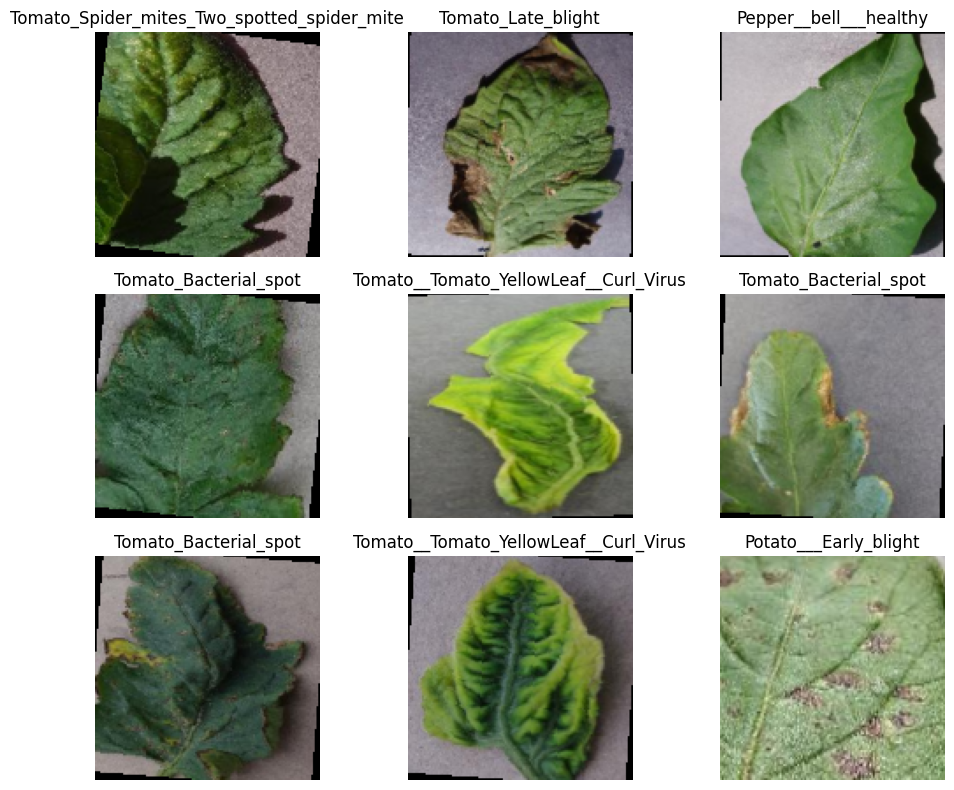

In [2]:
DATA_DIR = "PlantVillage"
IMG_SIZE = 128
BATCH_SIZE = 32
SEED = 42

if not os.path.isdir(DATA_DIR):
    raise FileNotFoundError(
        f"Dataset directory '{DATA_DIR}' not found. Set DATA_DIR to your plant disease dataset path."
    )

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transform)
class_names = full_dataset.classes
num_classes = len(class_names)
print("Classes:", class_names)
print("Number of classes:", num_classes)

train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED),
)
val_dataset.dataset = datasets.ImageFolder(DATA_DIR, transform=val_transform)
test_dataset.dataset = datasets.ImageFolder(DATA_DIR, transform=val_transform)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

sample_loader = DataLoader(train_dataset, batch_size=9, shuffle=True)
images, labels = next(iter(sample_loader))
plt.figure(figsize=(10, 8))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    img = np.clip(img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]), 0, 1)
    plt.imshow(img)
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

Preprocessing pipeline:
- Train: RandomResizedCrop + Flip + Rotation + Normalize
- Val/Test: Resize + Normalize
Batch image tensor shape: torch.Size([32, 3, 128, 128])
Batch labels shape: torch.Size([32])
Pixel value range (after normalization): -2.1179039478302 to 2.5877127647399902


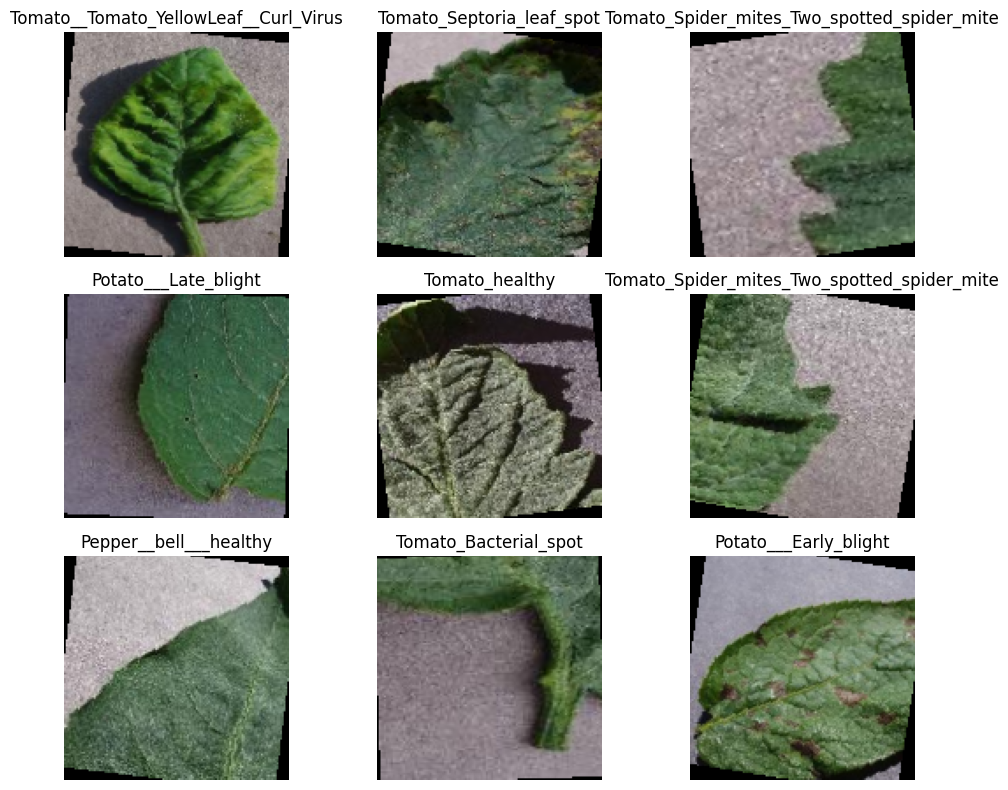

In [3]:
# Data cleaning/preprocessing is already handled by torchvision transforms
# in train_transform and val_transform from the previous cell.

print("Preprocessing pipeline:")
print("- Train: RandomResizedCrop + Flip + Rotation + Normalize")
print("- Val/Test: Resize + Normalize")

# Quick sanity check on one training batch
sanity_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
images, labels = next(iter(sanity_loader))
print("Batch image tensor shape:", images.shape)
print("Batch labels shape:", labels.shape)
print("Pixel value range (after normalization):", float(images.min()), "to", float(images.max()))

plt.figure(figsize=(10, 8))
for i in range(min(9, images.size(0))):
    ax = plt.subplot(3, 3, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    img = np.clip(img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]), 0, 1)
    plt.imshow(img)
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [4]:
pin_memory = device.type == "cuda"
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=pin_memory)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=pin_memory)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=pin_memory)

class CNNClassifier(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


model = CNNClassifier(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))
early_stop_patience = 4
best_val_acc = 0.0
best_state = None
counter = 0
train_losses, val_losses, train_accs, val_accs = [], [], [], []

print(f"Training on device: {device}")
print(f"pin_memory={pin_memory}")

for epoch in range(1, 16):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * labels.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * labels.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch}: train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = model.state_dict()
        counter = 0
    else:
        counter += 1
        if counter >= early_stop_patience:
            print("Early stopping triggered")
            break

if best_state is not None:
    model.load_state_dict(best_state)

print("Best validation accuracy:", round(best_val_acc, 4))

Training on device: cpu
pin_memory=False
Epoch 1: train_loss=1.3432, train_acc=0.5739, val_loss=1.0343, val_acc=0.6591
Epoch 2: train_loss=0.8790, train_acc=0.7174, val_loss=0.7351, val_acc=0.7577
Epoch 3: train_loss=0.6757, train_acc=0.7831, val_loss=0.3961, val_acc=0.8914
Epoch 4: train_loss=0.5738, train_acc=0.8184, val_loss=0.4431, val_acc=0.8649
Epoch 5: train_loss=0.4986, train_acc=0.8386, val_loss=0.3067, val_acc=0.9157
Epoch 6: train_loss=0.4492, train_acc=0.8572, val_loss=0.2754, val_acc=0.9250
Epoch 7: train_loss=0.4067, train_acc=0.8705, val_loss=0.2546, val_acc=0.9257
Epoch 8: train_loss=0.3823, train_acc=0.8769, val_loss=0.4623, val_acc=0.8410
Epoch 9: train_loss=0.3532, train_acc=0.8845, val_loss=0.2020, val_acc=0.9396
Epoch 10: train_loss=0.3307, train_acc=0.8915, val_loss=0.2107, val_acc=0.9467
Epoch 11: train_loss=0.3098, train_acc=0.9016, val_loss=0.2389, val_acc=0.9263
Epoch 12: train_loss=0.3166, train_acc=0.8955, val_loss=0.1643, val_acc=0.9593
Epoch 13: train_loss

Test accuracy: 0.96

Classification report:
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.98      0.92      0.95       140
                     Pepper__bell___healthy       1.00      0.98      0.99       241
                      Potato___Early_blight       1.00      0.92      0.96       156
                       Potato___Late_blight       0.96      0.95      0.95       168
                           Potato___healthy       0.95      0.95      0.95        22
                      Tomato_Bacterial_spot       0.99      0.94      0.97       335
                        Tomato_Early_blight       0.98      0.87      0.92       150
                         Tomato_Late_blight       0.89      0.99      0.94       274
                           Tomato_Leaf_Mold       0.97      0.95      0.96       139
                  Tomato_Septoria_leaf_spot       0.96      0.99      0.97       264
Tomato_Spider_mites_

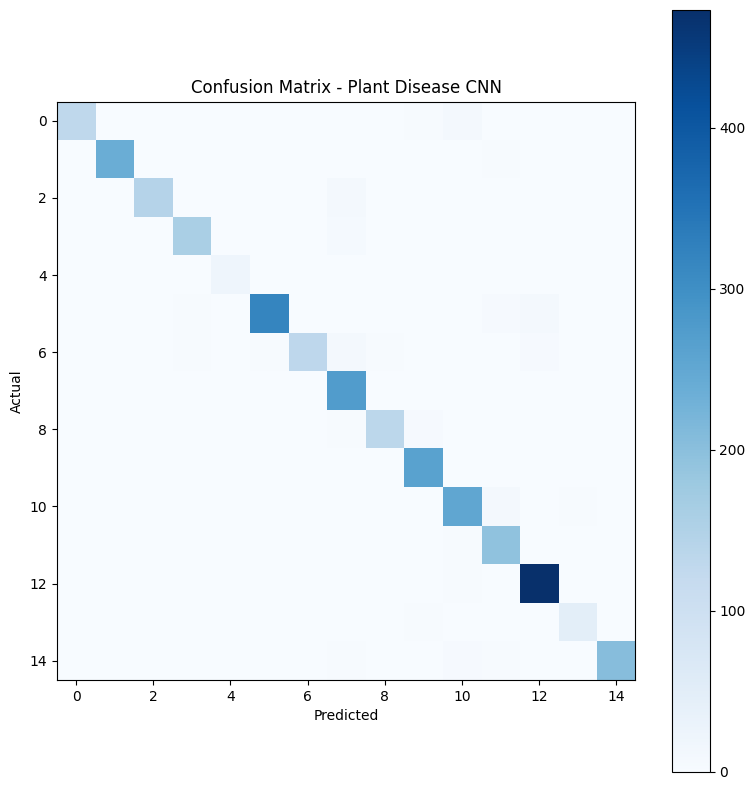

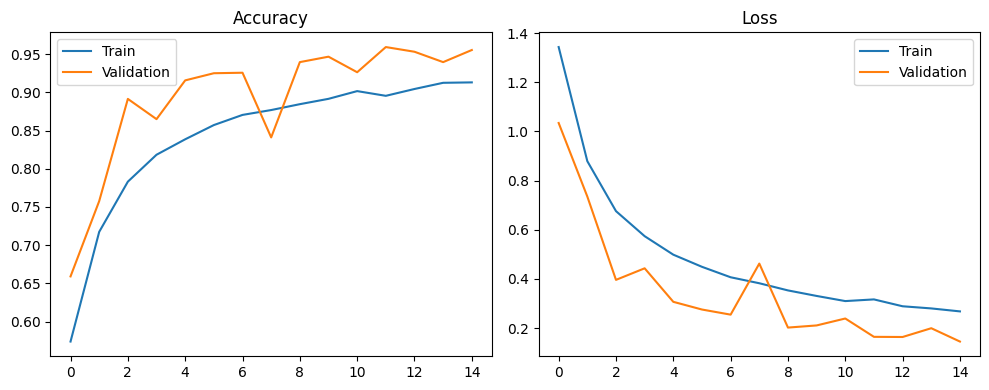

Sample predictions:
Actual: Tomato_Bacterial_spot, Predicted: Tomato_Bacterial_spot
Actual: Tomato_Leaf_Mold, Predicted: Tomato_Leaf_Mold
Actual: Potato___Late_blight, Predicted: Potato___Late_blight
Actual: Tomato_Late_blight, Predicted: Tomato_Late_blight
Actual: Tomato_Early_blight, Predicted: Tomato_Early_blight


In [5]:
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

accuracy = (np.array(all_preds) == np.array(all_labels)).mean()
cm = confusion_matrix(all_labels, all_preds)
print("Test accuracy:", round(float(accuracy), 4))
print("\nClassification report:")
print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

plt.figure(figsize=(8, 8))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - Plant Disease CNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_accs, label="Train")
plt.plot(val_accs, label="Validation")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.title("Loss")
plt.legend()
plt.tight_layout()
plt.show()

sample_indices = np.random.choice(len(test_dataset), size=5, replace=False)
print("Sample predictions:")
for idx in sample_indices:
    image, label = test_dataset[idx]
    with torch.no_grad():
        pred = model(image.unsqueeze(0).to(device)).argmax(dim=1).item()
    print(f"Actual: {class_names[label]}, Predicted: {class_names[pred]}")

# Fashion MNIST Classification Using CNN with PyTorch

This notebook builds a CNN to classify Fashion MNIST images into 10 clothing categories using PyTorch and CUDA when available.

In [6]:
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]
print("Libraries imported successfully.")

Libraries imported successfully.


Train shape: 60000 Test shape: 10000
Missing values in training labels: 0


C:\Users\jenil\AppData\Local\Temp\ipykernel_32420\1587851588.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  print("Missing values in training labels:", np.isnan(np.array(raw_train_ds.targets)).sum())


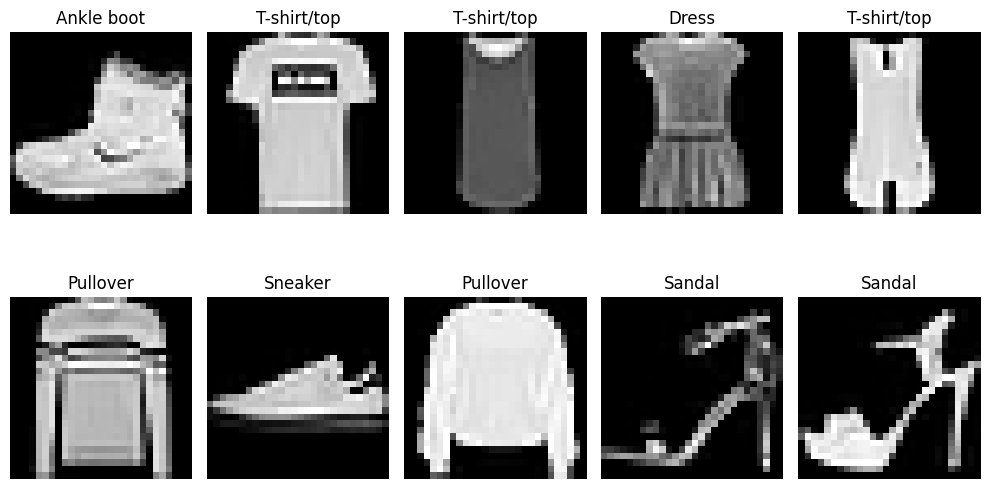

Training samples: 54000
Validation samples: 6000
Test samples: 10000


In [7]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

raw_train_ds = datasets.FashionMNIST(root="./data", train=True, download=True)
train_full_ds = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
test_ds = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

print("Train shape:", len(raw_train_ds), "Test shape:", len(test_ds))
print("Missing values in training labels:", np.isnan(np.array(raw_train_ds.targets)).sum())

plt.figure(figsize=(10, 6))
for i in range(10):
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(raw_train_ds.data[i].numpy(), cmap="gray")
    plt.title(class_names[raw_train_ds.targets[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

train_size = int(0.9 * len(train_full_ds))
val_size = len(train_full_ds) - train_size
train_ds, val_ds = random_split(train_full_ds, [train_size, val_size], generator=torch.Generator().manual_seed(42))

print("Training samples:", len(train_ds))
print("Validation samples:", len(val_ds))
print("Test samples:", len(test_ds))

In [8]:
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2, pin_memory=(device.type == "cuda"))
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=2, pin_memory=(device.type == "cuda"))
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=2, pin_memory=(device.type == "cuda"))

class CNNClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


model = CNNClassifier().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

print(model)

best_val_acc = 0.0
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(1, 8):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * labels.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * labels.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "fashion_mnist_cnn.pth")

    print(f"Epoch {epoch}: train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

print("Best validation accuracy:", round(best_val_acc, 4))

CNNClassifier(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1152, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


C:\Users\jenil\AppData\Local\Temp\ipykernel_32420\441318054.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))
C:\Users\jenil\AppData\Local\Temp\ipykernel_32420\441318054.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Epoch 1: train_loss=0.5537, train_acc=0.7978, val_loss=0.3483, val_acc=0.8712
Epoch 2: train_loss=0.3387, train_acc=0.8773, val_loss=0.3117, val_acc=0.8878
Epoch 3: train_loss=0.2888, train_acc=0.8957, val_loss=0.2594, val_acc=0.9017
Epoch 4: train_loss=0.2589, train_acc=0.9064, val_loss=0.2477, val_acc=0.9072
Epoch 5: train_loss=0.2346, train_acc=0.9140, val_loss=0.2235, val_acc=0.9168
Epoch 6: train_loss=0.2150, train_acc=0.9213, val_loss=0.2515, val_acc=0.9093
Epoch 7: train_loss=0.1923, train_acc=0.9295, val_loss=0.2161, val_acc=0.9217
Best validation accuracy: 0.9217


Test accuracy: 0.9162

Classification report:
              precision    recall  f1-score   support

 T-shirt/top       0.85      0.89      0.87      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.87      0.88      0.87      1000
       Dress       0.89      0.94      0.91      1000
        Coat       0.87      0.87      0.87      1000
      Sandal       0.99      0.98      0.98      1000
       Shirt       0.79      0.70      0.74      1000
     Sneaker       0.94      0.98      0.96      1000
         Bag       0.99      0.99      0.99      1000
  Ankle boot       0.98      0.95      0.96      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



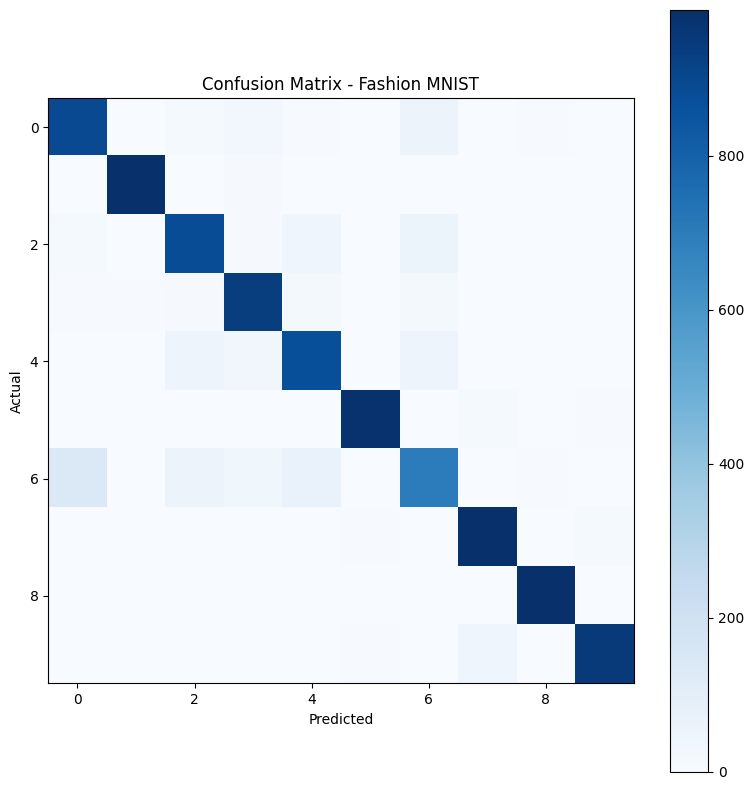

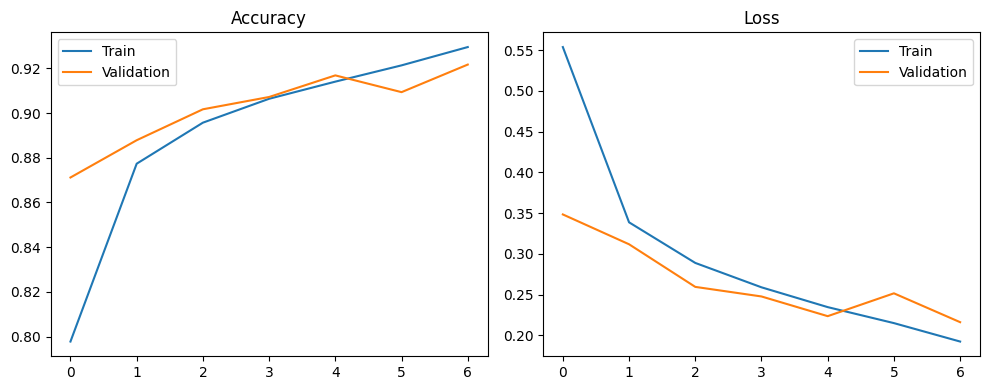

Sample predictions:
Actual: Shirt, Predicted: Shirt
Actual: Dress, Predicted: Dress
Actual: T-shirt/top, Predicted: T-shirt/top
Actual: Sandal, Predicted: Ankle boot
Actual: Pullover, Predicted: Pullover


In [9]:
model.load_state_dict(torch.load("fashion_mnist_cnn.pth", map_location=device))
model.eval()

all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

accuracy = accuracy_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)
print("Test accuracy:", round(accuracy, 4))
print("\nClassification report:")
print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

plt.figure(figsize=(8, 8))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - Fashion MNIST")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_accs, label="Train")
plt.plot(val_accs, label="Validation")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.title("Loss")
plt.legend()
plt.tight_layout()
plt.show()

sample_indices = np.random.choice(len(test_loader.dataset), size=5, replace=False)
print("Sample predictions:")
for idx in sample_indices:
    img, label = test_loader.dataset[idx]
    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device)).argmax(dim=1).item()
    print(f"Actual: {class_names[label]}, Predicted: {class_names[pred]}")